# Model description
The tight-binding model is written as:
$$
\begin{aligned}

H(\mathbf{k})&=\epsilon(\mathbf{k})\tau_x\otimes\sigma_0 + u\sin(k_x)\tau_y\otimes\sigma_x + u\sin(k_y)\tau_y\otimes\sigma_y \\

&\quad+ v\sin(k_z)\tau_y\otimes\sigma_z + m_z \tau_0\otimes\sigma_z + \delta\sin(k_z)\tau_y\otimes\sigma_0 \\

\epsilon(\mathbf{k})&=2.4-\cos(k_x)-\cos(k_y)+2\cos(k_z)\\

U_{S_4}&=\tau_x\otimes e^{-\text{i}\frac{\pi}{4}\sigma_z}

\end{aligned}$$

The last two terms break antiunitary time-reversal-like symmetry (TR symmetry + unitary transformation, namely $(\tau_x\otimes\sigma_y)\mathcal{K}$) and inversion symmetry ($\tau_x\otimes\sigma_0$). Now there is only S4 symmetry:
$$
U_{S_4}H(\bm{k})U_{S_4}^{-1}=H(S_4\bm{k})
$$
Let's first check the band and DOS, to make sure it's an insulator. Two bands at the bottom are occupied.

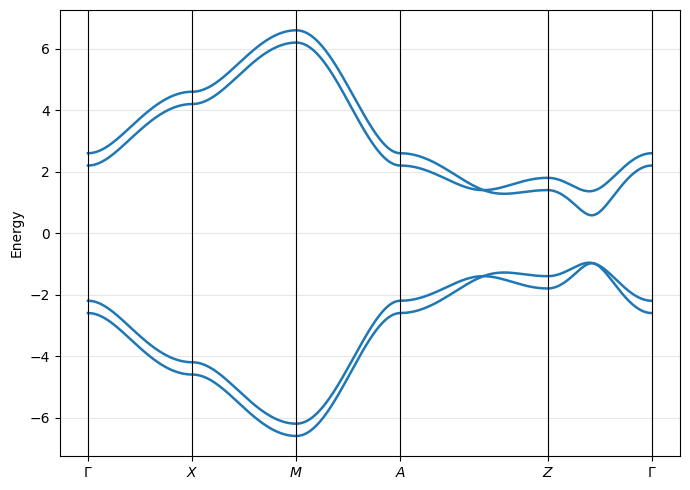

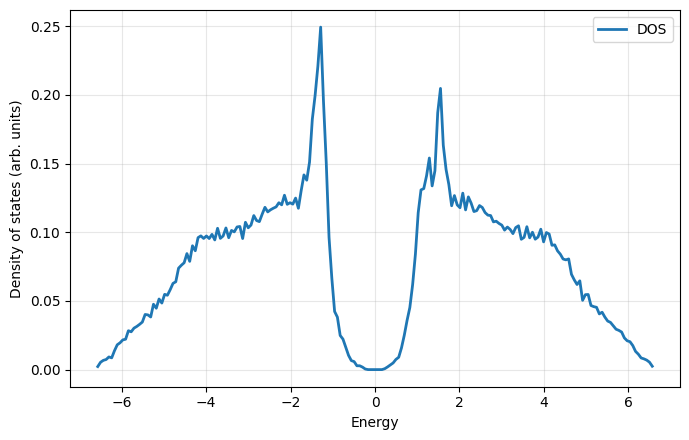

In [9]:
import numpy as np
import matplotlib.pyplot as plt

tau_x = np.array([[0, 1], [1, 0]], dtype=float)
tau_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_0 = np.eye(2, dtype=float)
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
spin_s4 = np.diag([np.exp(-1j * np.pi / 4), np.exp(1j * np.pi / 4)])
s4_operator = np.kron(tau_x.astype(complex), spin_s4)
s4_squared_operator = s4_operator @ s4_operator


def hamiltonian(kx,ky,kz):
    eps = 2.4 - np.cos(kx) - np.cos(ky) + 2 * np.cos(kz)
    return (
        eps * np.kron(tau_x, sigma_0)
		+ np.sin(kx) * np.kron(tau_y, sigma_x)
		+ np.sin(ky) * np.kron(tau_y, sigma_y)
		+ np.sin(kz) * np.kron(tau_y, sigma_z)
        + 0.2 * np.kron(sigma_0, sigma_z)
        + 0.2 * np.sin(kz) * np.kron(tau_y, sigma_0)
	)


def s4_k(kx, ky, kz):
	"""S4 action in momentum space used for the sewing matrix: (kx,ky,kz)->(ky,-kx,-kz)."""
	return ky, -kx, -kz


def s4_squared_k(kx, ky, kz):
	"""(S4)^2 action in momentum space: (kx,ky,kz)->(-kx,-ky,kz)."""
	return -kx, -ky, kz


def occupied_states(kx, ky, kz, hamiltonian_fn=hamiltonian, n_occ=2):
	"""Return occupied eigenvectors (columns) at momentum k."""
	eigvals, eigvecs = np.linalg.eigh(hamiltonian_fn(kx, ky, kz))
	order = np.argsort(eigvals.real)
	return eigvecs[:, order[:n_occ]]


def plot_band(
	hamiltonian_fn=hamiltonian,
	points=None,
	labels=None,
	n_per_segment=100,
	title=r"Bands along $\Gamma \rightarrow X \rightarrow M \rightarrow A \rightarrow Z \rightarrow \Gamma$",
):
	"""Plot band structure along a high-symmetry path."""
	# High-symmetry path: Γ -> X -> M -> A -> Z -> Γ
	# Γ = (0,0,0), X = (π,0,0), M = (π,π,0), A = (π,π,π), Z = (0,0,π)
	if points is None:
		points = [
			(0.0, 0.0, 0.0),
			(np.pi, 0.0, 0.0),
			(np.pi, np.pi, 0.0),
			(np.pi, np.pi, np.pi),
			(0.0, 0.0, np.pi),
			(0.0, 0.0, 0.0),
		]
	if labels is None:
		labels = [r"$\Gamma$", r"$X$", r"$M$", r"$A$", r"$Z$", r"$\Gamma$"]

	k_list = []
	k_ticks = [0.0]
	cumulative_distance = 0.0

	for seg_idx in range(len(points) - 1):
		k_start = np.array(points[seg_idx], dtype=float)
		k_end = np.array(points[seg_idx + 1], dtype=float)
		segment = np.linspace(k_start, k_end, n_per_segment, endpoint=False)
		k_list.append(segment)
		cumulative_distance += np.linalg.norm(k_end - k_start)
		k_ticks.append(float(cumulative_distance))

	k_list.append(np.array(points[-1], dtype=float)[None, :])
	k_path = np.vstack(k_list)

	x_axis = np.zeros(k_path.shape[0], dtype=float)
	for i in range(1, k_path.shape[0]):
		x_axis[i] = x_axis[i - 1] + np.linalg.norm(k_path[i] - k_path[i - 1])

	bands = np.zeros((4, k_path.shape[0]), dtype=float)
	for i, (kx, ky, kz) in enumerate(k_path):
		Hk = hamiltonian_fn(kx, ky, kz)
		bands[:, i] = np.linalg.eigvalsh(Hk).real

	plt.figure(figsize=(7, 5))
	for n in range(4):
		plt.plot(x_axis, bands[n], color="tab:blue", lw=1.8)

	for x_tick in k_ticks:
		plt.axvline(x_tick, color="k", lw=0.8)
	plt.xticks(k_ticks, labels)
	plt.ylabel("Energy")
	# plt.title(title)
	plt.grid(alpha=0.3)
	plt.tight_layout()
	plt.show()
	
def plot_DOS(hamiltonian_fn=hamiltonian, nk=50, nbins=200):
    # ---- DOS from hamiltonian_modified on a uniform 3D k-grid ----       
    # nk: k-points per direction (increase for smoother DOS)
    # nbins: number of energy bins for histogram

    k_grid = np.linspace(-np.pi, np.pi, nk, endpoint=False)
    energies = []

    for kx in k_grid:
        for ky in k_grid:
            for kz in k_grid:
                eigvals = np.linalg.eigvalsh(hamiltonian_fn(kx, ky, kz))
                energies.extend(eigvals.real)

    energies = np.asarray(energies)

    # Histogram DOS normalized as a probability density in energy.
    dos, bin_edges = np.histogram(energies, bins=nbins, density=True)
    E_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Optional light Gaussian smoothing (pure NumPy)
    sigma_bins = 1.2
    radius = int(max(3, np.ceil(4 * sigma_bins)))
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma_bins) ** 2)
    kernel /= kernel.sum()
    dos_smooth = np.convolve(dos, kernel, mode="same")

    plt.figure(figsize=(7, 4.5))
    plt.plot(E_centers, dos, lw=2, color="tab:blue", label="DOS")
    plt.xlabel("Energy")
    plt.ylabel("Density of states (arb. units)")
    # plt.title(f"DOS for hamiltonian_modified (nk={nk}, nbins={nbins})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_band()
plot_DOS()

# Visualization of eigenstates, sewing matrices...
## Visualize the eigenstates and sewing matrices at high-symmetry points
Before moving on, keeping the basis as $(c_{A,\uparrow},c_{A,\downarrow},c_{B,\uparrow},c_{B,\downarrow})$ where A,B correspond to $\tau$ and $\uparrow,\downarrow$ correspond to $\sigma$, let's first check:
1. the S4-symmetry of the hamiltonian. 
2. $S_4$ eigenvalue of each band among the two occupied bands, at $S_4$-invariant points: $\Gamma=(0,0,0),Z=(0,0,\pi),M=(\pi,\pi,0),A=(\pi,\pi,\pi)$, as well as the corresponding eigenstates
3. $C_2\equiv(S_4)^2$ eigenvalue of each band, at $C_2$-invariant points: $X=(\pi,0,0),R=(\pi,0,\pi),Y=(0,\pi,0),T=(0,\pi,\pi)$, as well as the corresponding eigenstates.

Noticeably, below, the sewing matrix $B_{mn}(\bm{k})=\langle u_m(S_4\bm{k}|S_4|u_n(\bm{k})\rangle$ for $S_4$ and $D_{mn}(\bm{k})=\langle u_m(C_2\bm{k})|C_2|u_n(\bm{k})\rangle$ for $C_2\equiv(S_4)^2$ are calculated by the way.

In [5]:
np.set_printoptions(precision=4, suppress=True)


def _wrap_to_pi(k):
    """Map momentum to principal zone (-pi, pi]."""
    return ((k + np.pi) % (2 * np.pi)) - np.pi


def _k_equiv(k1, k2, tol=1e-10):
    """Check k1 == k2 modulo reciprocal lattice vectors 2*pi*Z."""
    dk = np.array(k1, dtype=float) - np.array(k2, dtype=float)
    dk_wrapped = ((dk + np.pi) % (2 * np.pi)) - np.pi
    return np.max(np.abs(dk_wrapped)) < tol


def _complex_str(z, ndigits=6):
    return f"{z.real:.{ndigits}f}{z.imag:+.{ndigits}f}j"


def _occupied_spectrum(kx, ky, kz, hamiltonian_fn=hamiltonian, n_occ=2):
    eigvals, eigvecs = np.linalg.eigh(hamiltonian_fn(kx, ky, kz))
    order = np.argsort(eigvals.real)
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    return eigvals[:n_occ], eigvecs[:, :n_occ]


def _symmetry_subspace_analysis(k_point, symmetry_operator, hamiltonian_fn=hamiltonian, n_occ=2):
    """
    Diagonalize symmetry operator in occupied subspace.
    Returns occupied energies, symmetry eigenvalues, and symmetry-adapted occupied states.
    """
    kx, ky, kz = k_point
    occ_energies, U_occ = _occupied_spectrum(kx, ky, kz, hamiltonian_fn=hamiltonian_fn, n_occ=n_occ)

    # Project symmetry operator into occupied subspace.
    S_occ = U_occ.conj().T @ symmetry_operator @ U_occ

    sym_evals, sym_evecs = np.linalg.eig(S_occ)

    # Sort by phase angle for consistent output order.
    phases = np.angle(sym_evals)
    order = np.argsort(phases)
    sym_evals = sym_evals[order]
    sym_evecs = sym_evecs[:, order]

    # Symmetry-adapted occupied states in full 4-component basis.
    occ_states_sym_adapted = U_occ @ sym_evecs

    return occ_energies, sym_evals, occ_states_sym_adapted, S_occ


# ------------------------------------------------------------
# 1) Check S4 symmetry: U_S4 H(k) U_S4^{-1} = H(S4 k)
# ------------------------------------------------------------

test_points = [
    (0.0, 0.0, 0.0),
    (np.pi, 0.0, 0.0),
    (np.pi, np.pi, 0.0),
    (np.pi, np.pi, np.pi),
    (0.37, -1.21, 2.03),
    (-2.14, 1.57, -0.83),
]

print("=" * 90)
print("1) S4 symmetry check: U_S4 H(k) U_S4^{-1} ?= H(S4 k)")
print("=" * 90)

for kx, ky, kz in test_points:
    k_s4 = s4_k(kx, ky, kz)
    lhs = s4_operator @ hamiltonian(kx, ky, kz) @ np.linalg.inv(s4_operator)
    rhs = hamiltonian(*k_s4)
    err = np.linalg.norm(lhs - rhs)
    print(
        f"k=({kx:+.4f},{ky:+.4f},{kz:+.4f}) -> S4k=({k_s4[0]:+.4f},{k_s4[1]:+.4f},{k_s4[2]:+.4f}) | "
        f"||lhs-rhs||_F = {err:.3e}"
    )


# ------------------------------------------------------------
# 2) S4 eigenvalues/eigenstates at S4-invariant points
# ------------------------------------------------------------

s4_invariant_points = {
    "Gamma": (0.0, 0.0, 0.0),
    "Z": (0.0, 0.0, np.pi),
    "M": (np.pi, np.pi, 0.0),
    "A": (np.pi, np.pi, np.pi),
}

print("\n" + "=" * 90)
print("2) Occupied-band S4 eigenvalues/eigenstates at S4-invariant points")
print("=" * 90)

for name, kpt in s4_invariant_points.items():
    k_s4 = s4_k(*kpt)
    is_inv = _k_equiv(kpt, k_s4)
    print(f"\n{name}: k={kpt}, S4k={k_s4}, invariant(mod 2pi)={is_inv}")

    occ_E, s4_evals, s4_states, s4_occ_proj = _symmetry_subspace_analysis(
        kpt, s4_operator, hamiltonian_fn=hamiltonian, n_occ=2
    )

    print("   S4 occupied subspace projection S4_occ = U_occ^dagger S4 U_occ:")
    print(s4_occ_proj)

    print(f"  occupied energies: [{occ_E[0]:+.6f}, {occ_E[1]:+.6f}]")
    print("  S4 eigenvalues in occupied subspace:")
    for n, lam in enumerate(s4_evals, start=1):
        print(f"    occ state {n}: lambda_S4 = {_complex_str(lam)}")

    print("  corresponding occupied eigenstates (basis: [A_up, A_dn, B_up, B_dn]^T):")
    for n in range(2):
        vec = s4_states[:, n]
        comp_str = ", ".join(_complex_str(c) for c in vec)
        print(f"    occ state {n+1}: [{comp_str}]")


# ------------------------------------------------------------
# 3) C2 = (S4)^2 eigenvalues/eigenstates at C2-invariant points
# ------------------------------------------------------------

c2_invariant_points = {
    "X": (np.pi, 0.0, 0.0),
    "R": (np.pi, 0.0, np.pi),
    "Y": (0.0, np.pi, 0.0),
    "T": (0.0, np.pi, np.pi),
}

print("\n" + "=" * 90)
print("3) Occupied-band C2 eigenvalues/eigenstates at C2-invariant points")
print("=" * 90)

for name, kpt in c2_invariant_points.items():
    k_c2 = s4_squared_k(*kpt)
    is_inv = _k_equiv(kpt, k_c2)
    print(f"\n{name}: k={kpt}, C2k={k_c2}, invariant(mod 2pi)={is_inv}")

    occ_E, c2_evals, c2_states, c2_occ_proj = _symmetry_subspace_analysis(
        kpt, s4_squared_operator, hamiltonian_fn=hamiltonian, n_occ=2
    )

    print("   C2 occupied subspace projection C2_occ = U_occ^dagger C2 U_occ:")
    print(c2_occ_proj)

    print(f"  occupied energies: [{occ_E[0]:+.6f}, {occ_E[1]:+.6f}]")
    print("  C2 eigenvalues in occupied subspace:")
    for n, lam in enumerate(c2_evals, start=1):
        print(f"    occ state {n}: lambda_C2 = {_complex_str(lam)}")

    print("  corresponding occupied eigenstates (basis: [A_up, A_dn, B_up, B_dn]^T):")
    for n in range(2):
        vec = c2_states[:, n]
        comp_str = ", ".join(_complex_str(c) for c in vec)
        print(f"    occ state {n+1}: [{comp_str}]")


# Optional consistency check: C2 operator built from S4^2.
unitarity_err = np.linalg.norm(s4_squared_operator.conj().T @ s4_squared_operator - np.eye(4))
print("\n" + "-" * 90)
print(f"Consistency: ||(S4^2)^dagger (S4^2) - I||_F = {unitarity_err:.3e}")

1) S4 symmetry check: U_S4 H(k) U_S4^{-1} ?= H(S4 k)
k=(+0.0000,+0.0000,+0.0000) -> S4k=(+0.0000,-0.0000,-0.0000) | ||lhs-rhs||_F = 0.000e+00
k=(+3.1416,+0.0000,+0.0000) -> S4k=(+0.0000,-3.1416,-0.0000) | ||lhs-rhs||_F = 0.000e+00
k=(+3.1416,+3.1416,+0.0000) -> S4k=(+3.1416,-3.1416,-0.0000) | ||lhs-rhs||_F = 0.000e+00
k=(+3.1416,+3.1416,+3.1416) -> S4k=(+3.1416,-3.1416,-3.1416) | ||lhs-rhs||_F = 2.498e-16
k=(+0.3700,-1.2100,+2.0300) -> S4k=(-1.2100,-0.3700,-2.0300) | ||lhs-rhs||_F = 3.925e-16
k=(-2.1400,+1.5700,-0.8300) -> S4k=(+1.5700,+2.1400,+0.8300) | ||lhs-rhs||_F = 8.006e-16

2) Occupied-band S4 eigenvalues/eigenstates at S4-invariant points

Gamma: k=(0.0, 0.0, 0.0), S4k=(0.0, -0.0, -0.0), invariant(mod 2pi)=True
   S4 occupied subspace projection S4_occ = U_occ^dagger S4 U_occ:
[[-0.7071-0.7071j  0.    +0.j    ]
 [ 0.    +0.j     -0.7071+0.7071j]]
  occupied energies: [-2.600000, -2.200000]
  S4 eigenvalues in occupied subspace:
    occ state 1: lambda_S4 = -0.707107-0.707107j
 

## Visualize sewing matrices over the BZ
Next, I'd like to obtain the smooth sewing matrices $B(\bm{k})$ and $D(\bm{k})$ over the entire BZ. We need to be very careful about it, since the occupied states are calculated with an arbitrary gauge at each piont. 

In [6]:
def _unitary_part(matrix):
    """Return the unitary factor from polar decomposition via SVD."""
    u_mat, _, vh_mat = np.linalg.svd(matrix)
    return u_mat @ vh_mat


def _s4_index(ix, iy, iz, nk):
    """Return grid indices for S4(k): (ix,iy,iz)->(iy,-ix,-iz) modulo nk."""
    return iy % nk, (-ix) % nk, (-iz) % nk


def _c2_index(ix, iy, iz, nk):
    """Return grid indices for C2(k)=(S4)^2(k): (ix,iy,iz)->(-ix,-iy,iz) modulo nk."""
    return (-ix) % nk, (-iy) % nk, iz % nk


def _build_occupied_frames(nk=30, hamiltonian_fn=hamiltonian):
    """Build raw occupied frames U(k) on a periodic k-grid."""
    if nk < 4:
        raise ValueError("nk must be at least 4.")

    k_grid = np.linspace(-np.pi, np.pi, nk, endpoint=False)
    U = np.zeros((nk, nk, nk, 4, 2), dtype=complex)

    for ix, kx in enumerate(k_grid):
        for iy, ky in enumerate(k_grid):
            for iz, kz in enumerate(k_grid):
                U[ix, iy, iz] = occupied_states(kx, ky, kz, hamiltonian_fn=hamiltonian_fn)

    return k_grid, U


def _align_frame_to_reference(u_target, u_ref):
    """Rotate occupied frame u_target so overlap with u_ref is positive Hermitian."""
    overlap = u_ref.conj().T @ u_target
    q_mat = _unitary_part(overlap)
    return u_target @ q_mat.conj().T


def _smooth_frames_parallel_transport(U_raw):
    """Construct a smooth gauge by sequential parallel transport from (0,0,0)."""
    nk = U_raw.shape[0]
    U_smooth = np.zeros_like(U_raw)

    U_smooth[0, 0, 0] = U_raw[0, 0, 0]

    # 1) x-line at y=z=0
    for ix in range(1, nk):
        U_smooth[ix, 0, 0] = _align_frame_to_reference(U_raw[ix, 0, 0], U_smooth[ix - 1, 0, 0])

    # 2) y-lines on z=0 plane, for each fixed x
    for ix in range(nk):
        for iy in range(1, nk):
            U_smooth[ix, iy, 0] = _align_frame_to_reference(U_raw[ix, iy, 0], U_smooth[ix, iy - 1, 0])

    # 3) z-lines for each (x,y)
    for ix in range(nk):
        for iy in range(nk):
            for iz in range(1, nk):
                U_smooth[ix, iy, iz] = _align_frame_to_reference(U_raw[ix, iy, iz], U_smooth[ix, iy, iz - 1])

    return U_smooth


def build_smooth_sewing_matrices(nk=30, hamiltonian_fn=hamiltonian):
    """
    Build smooth sewing matrices over the whole BZ:
      B_mn(k)=<u_m(S4 k)|S4|u_n(k)>
      D_mn(k)=<u_m(C2 k)|C2|u_n(k)>
    using a smooth parallel-transport gauge for occupied states.
    """
    k_grid, U_raw = _build_occupied_frames(nk=nk, hamiltonian_fn=hamiltonian_fn)
    U_smooth = _smooth_frames_parallel_transport(U_raw)

    B = np.zeros((nk, nk, nk, 2, 2), dtype=complex)
    D = np.zeros((nk, nk, nk, 2, 2), dtype=complex)

    for ix in range(nk):
        for iy in range(nk):
            for iz in range(nk):
                ix_s4, iy_s4, iz_s4 = _s4_index(ix, iy, iz, nk)
                ix_c2, iy_c2, iz_c2 = _c2_index(ix, iy, iz, nk)

                u_k = U_smooth[ix, iy, iz]
                u_s4k = U_smooth[ix_s4, iy_s4, iz_s4]
                u_c2k = U_smooth[ix_c2, iy_c2, iz_c2]

                b_here = u_s4k.conj().T @ s4_operator @ u_k
                d_here = u_c2k.conj().T @ s4_squared_operator @ u_k

                # Re-unitarize to suppress floating-point drift.
                # B[ix, iy, iz] = _unitary_part(b_here)
                # D[ix, iy, iz] = _unitary_part(d_here)
                B[ix, iy, iz] = b_here
                D[ix, iy, iz] = d_here

    return k_grid, U_smooth, B, D


def sample_random_determinants(k_grid, B, D, n_samples=8, seed=1234):
    """Print det(B) and det(D) at random grid points."""
    nk = len(k_grid)
    rng = np.random.default_rng(seed)

    print("=" * 100)
    print(f"Random determinant samples on a {nk}^3 grid")
    print("=" * 100)

    for idx in range(1, n_samples + 1):
        ix = int(rng.integers(0, nk))
        iy = int(rng.integers(0, nk))
        iz = int(rng.integers(0, nk))

        kx, ky, kz = k_grid[ix], k_grid[iy], k_grid[iz]
        det_b = np.linalg.det(B[ix, iy, iz])
        det_d = np.linalg.det(D[ix, iy, iz])

        print(
            f"[{idx:02d}] k=({kx:+.4f},{ky:+.4f},{kz:+.4f}) | "
            f"det B={det_b.real:+.8f}{det_b.imag:+.8f}j, |det B|={abs(det_b):.8f} | "
            f"det D={det_d.real:+.8f}{det_d.imag:+.8f}j, |det D|={abs(det_d):.8f}"
        )


# # Build smooth sewing matrices and sample determinants.
# nk_mesh = 40
# k_grid, U_smooth, B_smooth, D_smooth = build_smooth_sewing_matrices(nk=nk_mesh)
# sample_random_determinants(k_grid, B_smooth, D_smooth, n_samples=12, seed=2026)

# # Optional quick global diagnostics.
# b_unitarity_err = np.max(np.abs(np.einsum("...ab,...cb->...ac", B_smooth.conj(), B_smooth) - np.eye(2)))
# d_unitarity_err = np.max(np.abs(np.einsum("...ab,...cb->...ac", D_smooth.conj(), D_smooth) - np.eye(2)))
# print("-" * 100)
# print(f"max|B^dagger B - I| entry over BZ = {b_unitarity_err:.3e}")
# print(f"max|D^dagger D - I| entry over BZ = {d_unitarity_err:.3e}")
# print("-" * 100)
# print(f"det B at (0,0,0) = {_complex_str(np.linalg.det(B_smooth[nk_mesh//2,nk_mesh//2,nk_mesh//2]))}")
# print(f"det D at (0,0,0) = {_complex_str(np.linalg.det(D_smooth[nk_mesh//2,nk_mesh//2,nk_mesh//2]))}")
# print(f"det B at (0,0,pi) = {_complex_str(np.linalg.det(B_smooth[nk_mesh//2,nk_mesh//2,-1]))}")
# print(f"det D at (0,0,pi) = {_complex_str(np.linalg.det(D_smooth[nk_mesh//2,nk_mesh//2,-1]))}")
# print(f"det B at (pi,pi,0) = {_complex_str(np.linalg.det(B_smooth[-1,-1,nk_mesh//2]))}")
# print(f"det D at (pi,pi,0) = {_complex_str(np.linalg.det(D_smooth[-1,-1,nk_mesh//2]))}")
# print(f"det B at (pi,pi,pi) = {_complex_str(np.linalg.det(B_smooth[-1,-1,-1]))}")
# print(f"det D at (pi,pi,pi) = {_complex_str(np.linalg.det(D_smooth[-1,-1,-1]))}")
# print(f"det D at (pi,0,0) = {_complex_str(np.linalg.det(D_smooth[-1,nk_mesh//2,nk_mesh//2]))}")
# print(f"det D at (pi,0,pi) = {_complex_str(np.linalg.det(D_smooth[-1,nk_mesh//2,-1]))}")

## Additional visualization
It seems that the states are generally smooth at the boundary? Some difference is expected for (pi,pi,0) and (pi,-pi,0) because the end of the grid doesn't fall exactly on pi.

In [4]:
# temporary test cell
print("-" * 100)
print("occupied states at (pi,pi,0):")
print(occupied_states(np.pi, np.pi, 0))
print("occupied states at (pi,pi,0) in smooth gauge:")
print(U_smooth[-1, -1, nk_mesh//2])
print("occupied states at (pi,-pi,0):")
print(occupied_states(np.pi, -np.pi, 0))
print("occupied states at (pi,-pi,0) in smooth gauge:")
print(U_smooth[-1, 0, nk_mesh//2])

----------------------------------------------------------------------------------------------------
occupied states at (pi,pi,0):
[[ 0.    +0.j     -0.7071+0.j    ]
 [-0.3162+0.6325j  0.    +0.j    ]
 [ 0.    +0.j      0.7071+0.j    ]
 [ 0.3162-0.6325j -0.    +0.j    ]]
occupied states at (pi,pi,0) in smooth gauge:


NameError: name 'U_smooth' is not defined

# $2P_3$ calculation
## $2P_3$ calculation - direct calculation from smoothed states ($\Rightarrow 2P_3=0$)
I don't know yet why it gives 0.

With the smooth sewing matrices obtained above, let's calculate
$$
2P_3=-\frac{1}{24\pi^2}\int d^3\bm{k} \epsilon^{ijk} Tr[(B^\dagger\partial_i B)(B^\dagger\partial_j B)(B^\dagger\partial_k B)]
$$
where $\partial_i=\frac{\partial}{\partial k_i}$, and the integral conducted over the entire BZ.

In [10]:
def _central_diff_periodic(arr, axis, dk):
    """Periodic central difference along one lattice direction."""
    return (np.roll(arr, -1, axis=axis) - np.roll(arr, 1, axis=axis)) / (2.0 * dk)

def _central_diff(arr, axis, dk):
    """Central difference along one lattice direction with zero boundary conditions."""
    diff = np.zeros_like(arr)
    slc_plus = [slice(None)] * arr.ndim
    slc_minus = [slice(None)] * arr.ndim
    slc_plus[axis] = slice(1, None)
    slc_minus[axis] = slice(None, -1)
    diff[tuple(slc_plus)] = (arr[tuple(slc_plus)] - arr[tuple(slc_minus)]) / dk
    return diff

def compute_two_p3_from_B(B, k_grid):
    """
    Numerically evaluate
      2P3 = -(1/24π^2) ∫ d^3k ε^{ijk} Tr[(B†∂iB)(B†∂jB)(B†∂kB)]
    on a uniform periodic k-grid.

    Parameters
    ----------
    B : ndarray, shape (nk, nk, nk, n, n)
        Smooth sewing matrix field (typically n=2).
    k_grid : ndarray, shape (nk,)
        Uniform k points in each direction.
    """
    nk = len(k_grid)
    dk = float(k_grid[1] - k_grid[0])

    # Ordinary derivatives of B (not covariant derivatives).
    dBx = _central_diff_periodic(B, axis=0, dk=dk)
    dBy = _central_diff_periodic(B, axis=1, dk=dk)
    dBz = _central_diff_periodic(B, axis=2, dk=dk)

    B_dag = np.swapaxes(B.conj(), -1, -2)
    A_x = np.einsum("...ab,...bc->...ac", B_dag, dBx)
    A_y = np.einsum("...ab,...bc->...ac", B_dag, dBy)
    A_z = np.einsum("...ab,...bc->...ac", B_dag, dBz)

    # # We only calculate the integral in [0,\pi]^3
    # A_x = A_x[nk // 2 :, nk // 2 :, nk // 2 :]
    # A_y = A_y[nk // 2 :, nk // 2 :, nk // 2 :]
    # A_z = A_z[nk // 2 :, nk // 2 :, nk // 2 :]

    # ε^{ijk} Tr[A_i A_j A_k] = Tr(AxAyAz + AyAzAx + AzAxAy - AxAzAy - AzAyAx - AyAxAz)
    term = (
        np.trace(np.einsum("...ab,...bc,...cd->...ad", A_x, A_y, A_z), axis1=-2, axis2=-1)
        + np.trace(np.einsum("...ab,...bc,...cd->...ad", A_y, A_z, A_x), axis1=-2, axis2=-1)
        + np.trace(np.einsum("...ab,...bc,...cd->...ad", A_z, A_x, A_y), axis1=-2, axis2=-1)
        - np.trace(np.einsum("...ab,...bc,...cd->...ad", A_x, A_z, A_y), axis1=-2, axis2=-1)
        - np.trace(np.einsum("...ab,...bc,...cd->...ad", A_z, A_y, A_x), axis1=-2, axis2=-1)
        - np.trace(np.einsum("...ab,...bc,...cd->...ad", A_y, A_x, A_z), axis1=-2, axis2=-1)
    )

    integral = np.sum(term) * (dk ** 3)
    two_p3 = -(1.0 / (24.0 * np.pi ** 2)) * integral

    # For unitary B, result should be real; keep tiny imaginary part as numerical diagnostic.
    return two_p3


# Use smooth B(k) from cell 6 if available, otherwise build it.
if "B_smooth" not in globals() or "k_grid" not in globals():
    nk_mesh = 40
    k_grid, U_smooth, B_smooth, D_smooth = build_smooth_sewing_matrices(nk=nk_mesh)


# two_p3_val = compute_two_p3_from_B(B_smooth, k_grid)
# print("=" * 90)
# print("2P3 from smooth sewing matrix B(k)")
# print("=" * 90)
# print(f"2P3 = {two_p3_val.real:+.10f} {two_p3_val.imag:+.3e}j")
# print(f"Re(2P3) = {two_p3_val.real:+.10f}")
# print(f"Im(2P3) = {two_p3_val.imag:+.3e}  (numerical error check)")
# print(f"Nearest integer to Re(2P3): {int(np.rint(two_p3_val.real))}")

## $2P_3$ calculation - Wilson Loop ($\Rightarrow 2P_3=1$)
To test the topology in another way, we calculate Wilson Loop along z:
$$
W_z(k_x,k_y)=\exp\left(\text{i}\int_{0}^{2\pi}A_z(k_x,k_y,k_z)dk_z\right)\\
[A_z(\bm{k})]_{mn}=\text{i}\langle u_{m\bm{k}}|\partial_{k_z}|u_{n\bm{k}}\rangle
$$
The 2x2 matrix $W_z$ has eigenvalues $e^{i\theta}$, the two $\theta(x,y)$ form the Wilson spectrum. We'll plot: 
$\theta_{1,2}$ along high-symmetry line in x-y plane: $\Gamma(0,0)\rightarrow X(\pi,0)\rightarrow M(\pi,\pi)\rightarrow Y(0,\pi)$

As can be seen as follows, there are odd number of Dirac points in the Wilson spectrum on x-y plane, reassuring its topological nature.

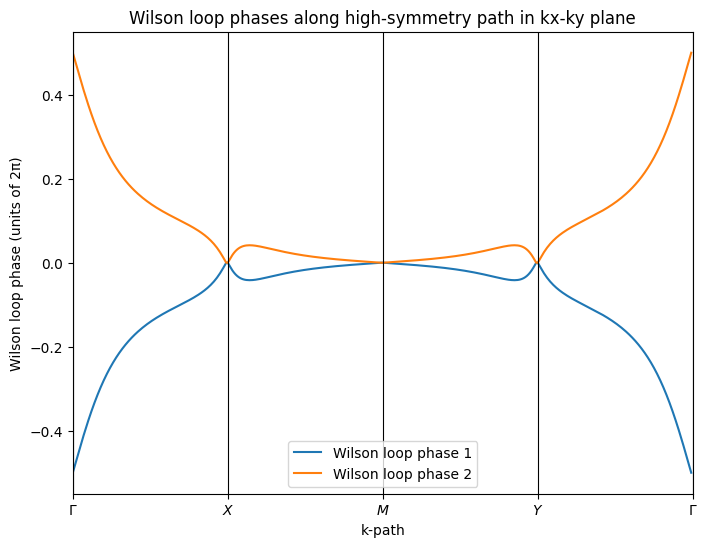

In [ ]:
import matplotlib.pyplot as plt

def wilson_loop_eigenvalues(kx, ky, hamiltonian_fn=hamiltonian, nkz=50, n_occ=2):
    '''Compute Wilson loop eigenvalues along kz for fixed (kx, ky).
    Returns sorted phases (in units of 2π) of the Wilson loop eigenvalues, which is an np.array of shape (n_occ,).'''
    kz_vals = np.linspace(-np.pi, np.pi, nkz, endpoint=False)
        
    Mz = np.eye(n_occ, dtype=complex)
    u_prev = None
    u_0 = None

    for kz in kz_vals:
        u_k = occupied_states(kx, ky, kz, hamiltonian_fn=hamiltonian_fn, n_occ=n_occ)
        if u_prev is None:
            u_prev = u_k
            u_0 = u_k
            continue

        # S = _unitary_part(u_prev.conj().T @ u_k)
        S = u_prev.conj().T @ u_k
        Mz = Mz @ S
        u_prev = u_k

    # S_close = _unitary_part(u_prev.conj().T @ u_0)
    S_close = u_prev.conj().T @ u_0
    Mz = Mz @ S_close

    eigvals = np.linalg.eigvals(Mz)
    phases = np.sort(np.angle(eigvals) / (2.0 * np.pi))

    return phases

def plot_wilson_loop_phases(hamiltonian_fn=hamiltonian, nk_line=100):
    # PLotting along high-symmetry path in kx-ky plane 
    plt.figure(figsize=(8, 6))
    high_symmetry_path = [
        (0.0, 0.0),  # Γ
        (np.pi, 0.0),  # X
        (np.pi, np.pi),  # M
        (0.0, np.pi), # Y
        (0.0, 0.0),  # Γ
    ]
    labels = [r"$\Gamma$", r"$X$", r"$M$", r"$Y$", r"$\Gamma$"]
    kx_path = []
    ky_path = []
    for start, end in zip(high_symmetry_path[:-1], high_symmetry_path[1:]):
        kx_start, ky_start = start
        kx_end, ky_end = end
        for t in np.linspace(0, 1, nk_line):
            kx_path.append(kx_start + t * (kx_end - kx_start))
            ky_path.append(ky_start + t * (ky_end - ky_start))
    kx_path = np.array(kx_path)
    ky_path = np.array(ky_path)
    wilson_phases_path = np.zeros((len(kx_path), 2), dtype=float)
    for i, (kx, ky) in enumerate(zip(kx_path, ky_path)):
        wilson_phases_path[i] = wilson_loop_eigenvalues(kx, ky, hamiltonian_fn=hamiltonian_fn, nkz=50, n_occ=2)

    x_axis = np.arange(len(kx_path))
    plt.plot(x_axis, wilson_phases_path[:, 0], label="Wilson loop phase 1", color="tab:blue")
    plt.plot(x_axis, wilson_phases_path[:, 1], label="Wilson loop phase 2", color="tab:orange")

    segment_length = nk_line
    tick_positions = np.arange(len(labels)) * segment_length
    for x in tick_positions:
        plt.axvline(x, color="k", lw=0.8)

    plt.xticks(tick_positions, labels)
    plt.xlim(0, len(kx_path))
    plt.xlabel("k-path")
    plt.ylabel("Wilson loop phase (units of 2π)")
    plt.title("Wilson loop phases along high-symmetry path in kx-ky plane")
    plt.legend()
    plt.show()

plot_wilson_loop_phases()

## $2P_3$ calculation - Cartan 3-form using link variables ($\Rightarrow 2P_3=0$)
Recalculate $2P_3$ with another method: Cartan 3-form on a discrete lattice using generalized link variables.

In [6]:
def _log_unitary_principal(U):
    """Principal-branch matrix log for a unitary 2x2 matrix (anti-Hermitian output)."""
    evals, evecs = np.linalg.eig(U)
    phases = np.angle(evals)
    logU = evecs @ np.diag(1j * phases) @ np.linalg.inv(evecs)
    return 0.5 * (logU - logU.conj().T)


def _build_generalized_links(B):
    """Generalized links L_i(k) = B(k)^dagger B(k+e_i)."""
    Bdag = np.swapaxes(B.conj(), -1, -2)
    Lx = np.einsum("...ab,...bc->...ac", Bdag, np.roll(B, -1, axis=0))
    Ly = np.einsum("...ab,...bc->...ac", Bdag, np.roll(B, -1, axis=1))
    Lz = np.einsum("...ab,...bc->...ac", Bdag, np.roll(B, -1, axis=2))
    return Lx, Ly, Lz


def _log_links(L):
    """Apply principal matrix log to every link matrix on the periodic lattice."""
    nk = L.shape[0]
    A = np.zeros_like(L, dtype=complex)
    max_abs_phase = 0.0
    for ix in range(nk):
        for iy in range(nk):
            for iz in range(nk):
                lam = np.linalg.eigvals(L[ix, iy, iz])
                max_abs_phase = max(max_abs_phase, float(np.max(np.abs(np.angle(lam)))))
                A[ix, iy, iz] = _log_unitary_principal(L[ix, iy, iz])
    return A, max_abs_phase


def _eps_trace_triple(Ax, Ay, Az):
    """epsilon^{ijk} Tr[A_i A_j A_k] with explicit antisymmetrization."""
    return (
        np.trace(Ax @ Ay @ Az)
        + np.trace(Ay @ Az @ Ax)
        + np.trace(Az @ Ax @ Ay)
        - np.trace(Ax @ Az @ Ay)
        - np.trace(Az @ Ay @ Ax)
        - np.trace(Ay @ Ax @ Az)
    )


def compute_two_p3_cartan_cube_log(B, k_grid):
    """
    Discrete Cartan 3-form for B(k) using generalized links and matrix logs.

    1) L_i(k) = B(k)^dagger B(k+e_i)
    2) A_i(k) = log(L_i(k))
    3) For each cube, average A_i over its 4 edges parallel to i
    4) Sum -(1/24pi^2) * epsilon^{ijk} Tr[A_i A_j A_k] * dV
    """
    nk = len(k_grid)
    dk = float(k_grid[1] - k_grid[0])

    Lx, Ly, Lz = _build_generalized_links(B)
    Ax_edge, max_phase_x = _log_links(Lx)
    Ay_edge, max_phase_y = _log_links(Ly)
    Az_edge, max_phase_z = _log_links(Lz)

    # Cube-centered generators from 4 parallel edges.
    Ax_cube = 0.25 * (
        Ax_edge
        + np.roll(Ax_edge, -1, axis=1)
        + np.roll(Ax_edge, -1, axis=2)
        + np.roll(np.roll(Ax_edge, -1, axis=1), -1, axis=2)
    )
    Ay_cube = 0.25 * (
        Ay_edge
        + np.roll(Ay_edge, -1, axis=0)
        + np.roll(Ay_edge, -1, axis=2)
        + np.roll(np.roll(Ay_edge, -1, axis=0), -1, axis=2)
    )
    Az_cube = 0.25 * (
        Az_edge
        + np.roll(Az_edge, -1, axis=0)
        + np.roll(Az_edge, -1, axis=1)
        + np.roll(np.roll(Az_edge, -1, axis=0), -1, axis=1)
    )

    density = np.zeros((nk, nk, nk), dtype=float)
    for ix in range(nk):
        for iy in range(nk):
            for iz in range(nk):
                cartan_here = _eps_trace_triple(Ax_cube[ix, iy, iz], Ay_cube[ix, iy, iz], Az_cube[ix, iy, iz])
                density[ix, iy, iz] = float(np.real(cartan_here))

    integral = np.sum(density) * (dk ** 3)
    two_p3 = -(1.0 / (24.0 * np.pi ** 2)) * integral

    diagnostics = {
        "max_abs_phase_x": max_phase_x,
        "max_abs_phase_y": max_phase_y,
        "max_abs_phase_z": max_phase_z,
        "density_min": float(np.min(density)),
        "density_max": float(np.max(density)),
    }
    return two_p3, diagnostics


# Use existing B_smooth if present.
if "B_smooth" not in globals() or "k_grid" not in globals():
    nk_mesh = 40
    k_grid, U_smooth, B_smooth, D_smooth = build_smooth_sewing_matrices(nk=nk_mesh)


two_p3_cube, diag_cube = compute_two_p3_cartan_cube_log(B_smooth, k_grid)

print("=" * 96)
print("Discrete Cartan 3-form (cube-log generalized links) for 2P3")
print("=" * 96)
print(f"2P3 (cube-log) = {two_p3_cube:+.10f}")
print("Branch diagnostics (max |phase| of link eigenvalues, radians):")
print(
    f"  x: {diag_cube['max_abs_phase_x']:.6f}, "
    f"y: {diag_cube['max_abs_phase_y']:.6f}, "
    f"z: {diag_cube['max_abs_phase_z']:.6f}"
)
print(f"density range: [{diag_cube['density_min']:+.3e}, {diag_cube['density_max']:+.3e}]")
print(f"Nearest integer to 2P3: {int(np.rint(two_p3_cube))}")

KeyboardInterrupt: 

## $2P_3$ calculation - Projector to get a smooth occupied-state frame ($\Rightarrow 2P_3=1$)
I still don't know why the $2P_3$ calculated from a smoothed frame and from cartan-3 forms return 0, which contradict with theoretical prediction and the Wilson-loop result. I'll use analytical projector-smooth-frame method for the non-chiral block Hamiltonian.

Notice that the hamiltonian can be blocked into:
$$
H(\mathbf{k})=\begin{pmatrix}m_z\sigma_z & q(\mathbf{k})\\ q(\mathbf{k})^\dagger & m_z\sigma_z\end{pmatrix},\quad
q=\epsilon\sigma_0-i\sin k_x\,\sigma_x-i\sin k_y\,\sigma_y-i\sin k_z\,\sigma_z-i\delta\sin k_z\,\sigma_0,
$$
we do not use the chiral closed-form frame $[-Q;I]/\sqrt{2}$. Instead, we construct a smooth occupied frame from the spectral projector
$$
P_\mathrm{occ}(\mathbf{k})=\frac{1}{2}\left[I-H(H^2)^{-1/2}\right],
$$
then orthonormalize $W=P_\mathrm{occ}R$ with a fixed reference $R\in\mathbb{C}^{4\times 2}$:
$$
U_\mathrm{occ}=W\,(W^\dagger W)^{-1/2}.
$$
This gives a smooth occupied-state frame (away from singular overlap points) for sewing-matrix and $2P_3$ evaluation.

In [11]:
def hamiltonian_block_nonchiral(kx, ky, kz, mz=0.2, delta=0.2):
    """H = [[mz*sigma_z, q],[q^dagger, mz*sigma_z]] for the requested non-chiral model."""
    eps = 2.4 - np.cos(kx) - np.cos(ky) + 2.0 * np.cos(kz)
    q_mat = (
        eps * sigma_0
        - 1j * np.sin(kx) * sigma_x
        - 1j * np.sin(ky) * sigma_y
        - 1j * np.sin(kz) * sigma_z
        - 1j * delta * np.sin(kz) * sigma_0
    )
    mblock = mz * sigma_z
    return np.block([[mblock, q_mat], [q_mat.conj().T, mblock]])


def _inverse_sqrt_hermitian(mat, tol=1e-12):
    """Hermitian inverse square root using eigendecomposition."""
    evals, evecs = np.linalg.eigh(mat)
    if np.min(evals) < tol:
        raise ValueError("H^2 is near-singular; bulk gap may close.")
    return evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.conj().T


def smooth_occupied_frame_projector(kx, ky, kz, mz=0.2, delta=0.2, ref=None, tol=1e-10):
    """Projector-based smooth occupied frame U_occ(k) for the non-chiral block Hamiltonian."""
    Hk = hamiltonian_block_nonchiral(kx, ky, kz, mz=mz, delta=delta)
    Qflat = Hk @ _inverse_sqrt_hermitian(Hk @ Hk, tol=tol)
    P_occ = 0.5 * (np.eye(4, dtype=complex) - Qflat)

    if ref is None:
        ref = np.array(
            [[1.0, 0.0], [0.0, 1.0], [0.0, 0.0], [0.0, 0.0]],
            dtype=complex,
        )

    W = P_occ @ ref
    gram = W.conj().T @ W
    g_eval, g_vec = np.linalg.eigh(gram)
    if np.min(g_eval) < tol:
        raise ValueError("Reference overlap became singular; use a patched multi-chart gauge.")
    gram_inv_sqrt = g_vec @ np.diag(1.0 / np.sqrt(g_eval)) @ g_vec.conj().T
    return W @ gram_inv_sqrt


def build_B_projector_nonchiral(nk=48, mz=0.2, delta=0.2):
    """Build sewing matrix B(k)=<u(S4k)|S4|u(k)> from projector-smooth frames."""
    k_grid_local = np.linspace(-np.pi, np.pi, nk, endpoint=False)
    U_proj = np.zeros((nk, nk, nk, 4, 2), dtype=complex)
    B_proj = np.zeros((nk, nk, nk, 2, 2), dtype=complex)
    D_proj = np.zeros((nk, nk, nk, 2, 2), dtype=complex)

    ref = np.array(
        [[1.0, 0.0], [0.0, 1.0], [0.0, 0.0], [0.0, 0.0]],
        dtype=complex,
    )

    min_gap = np.inf
    min_overlap_eval = np.inf

    for ix, kx in enumerate(k_grid_local):
        for iy, ky in enumerate(k_grid_local):
            for iz, kz in enumerate(k_grid_local):
                Hk = hamiltonian_block_nonchiral(kx, ky, kz, mz=mz, delta=delta)
                gap_here = np.min(np.abs(np.linalg.eigvalsh(Hk)))
                min_gap = min(min_gap, float(gap_here))

                U_here = smooth_occupied_frame_projector(kx, ky, kz, mz=mz, delta=delta, ref=ref)
                U_proj[ix, iy, iz] = U_here

                # Track conditioning of overlap matrix in construction.
                overlap_eval_min = np.min(np.linalg.eigvalsh((U_here.conj().T @ U_here).real))
                min_overlap_eval = min(min_overlap_eval, float(overlap_eval_min))

    for ix in range(nk):
        for iy in range(nk):
            for iz in range(nk):
                ix_s4, iy_s4, iz_s4 = _s4_index(ix, iy, iz, nk)
                B_proj[ix, iy, iz] = U_proj[ix_s4, iy_s4, iz_s4].conj().T @ s4_operator @ U_proj[ix, iy, iz]
                D_proj[ix, iy, iz] = U_proj[_c2_index(ix, iy, iz, nk)].conj().T @ s4_squared_operator @ U_proj[ix, iy, iz]

    # Smooth det=1 normalization for stable winding evaluation.
    phase = np.angle(np.linalg.det(B_proj))
    phase = np.unwrap(phase, axis=0)
    phase = np.unwrap(phase, axis=1)
    phase = np.unwrap(phase, axis=2)
    B_proj_det1 = np.exp(-0.5j * phase)[..., None, None] * B_proj

    diagnostics = {
        "min_gap": min_gap,
        "min_overlap_eval": min_overlap_eval,
        "max_B_unitarity": float(np.max(np.abs(np.einsum("...ab,...cb->...ac", B_proj.conj(), B_proj) - np.eye(2)))),
        "max_Bdet1_unitarity": float(np.max(np.abs(np.einsum("...ab,...cb->...ac", B_proj_det1.conj(), B_proj_det1) - np.eye(2)))),
    }
    return k_grid_local, U_proj, B_proj, D_proj, B_proj_det1, diagnostics


# Run requested method.
nk_proj = 48
k_proj, U_proj, B_proj, D_proj, B_proj_det1, diag_proj = build_B_projector_nonchiral(nk=nk_proj, mz=0.2, delta=0.2)
two_p3_proj = compute_two_p3_from_B(B_proj, k_proj)
two_p3_proj_det1 = compute_two_p3_from_B(B_proj_det1, k_proj)

print("=" * 96)
print("Projector-smooth-frame method for non-chiral block Hamiltonian")
print("=" * 96)
print(f"nk = {nk_proj}")
print(f"min direct gap |E| over grid = {diag_proj['min_gap']:.6e}")
print(f"min eig(U^dag U) over grid   = {diag_proj['min_overlap_eval']:.6e}")
print(f"max|B^dag B-I| entry         = {diag_proj['max_B_unitarity']:.3e}")
print(f"max|Bdet1^dag Bdet1-I| entry = {diag_proj['max_Bdet1_unitarity']:.3e}")
print("-" * 96)
print(f"2P3 from projector B      = {two_p3_proj.real:+.10f} {two_p3_proj.imag:+.3e}j")
print(f"2P3 from projector B_det1 = {two_p3_proj_det1.real:+.10f} {two_p3_proj_det1.imag:+.3e}j")
print(f"Nearest integer (det1)    = {int(np.rint(two_p3_proj_det1.real))}")


# Show what the occupied-state frame looks like at representative k-points.
sample_points = {
    "Gamma": (0.0, 0.0, 0.0),
    "Z": (0.0, 0.0, np.pi),
    "M": (np.pi, np.pi, 0.0),
    "A": (np.pi, np.pi, np.pi),
}
print("\n" + "=" * 96)
print("Occupied-state frame columns (4-component vectors) at high-symmetry points")
print("Rows correspond to [A_up, A_dn, B_up, B_dn], columns are occupied states 1,2")
print("=" * 96)
for label, (kx, ky, kz) in sample_points.items():
    U_here = smooth_occupied_frame_projector(kx, ky, kz, mz=0.2, delta=0.2)
    print(f"\n{label}: k=({kx:+.3f}, {ky:+.3f}, {kz:+.3f})")
    print(np.array2string(U_here, precision=5, suppress_small=True))
    print(f"U^dag U =\n{np.array2string(U_here.conj().T @ U_here, precision=5, suppress_small=True)}")

Projector-smooth-frame method for non-chiral block Hamiltonian
nk = 48
min direct gap |E| over grid = 2.000000e-01
min eig(U^dag U) over grid   = 1.000000e+00
max|B^dag B-I| entry         = 3.109e-15
max|Bdet1^dag Bdet1-I| entry = 3.331e-15
------------------------------------------------------------------------------------------------
2P3 from projector B      = -0.9733207957 +1.177e-18j
2P3 from projector B_det1 = -0.9736265675 -2.078e-18j
Nearest integer (det1)    = -1

Occupied-state frame columns (4-component vectors) at high-symmetry points
Rows correspond to [A_up, A_dn, B_up, B_dn], columns are occupied states 1,2

Gamma: k=(+0.000, +0.000, +0.000)
[[ 0.70711+0.j  0.     +0.j]
 [ 0.     +0.j  0.70711+0.j]
 [-0.70711+0.j  0.     +0.j]
 [ 0.     +0.j -0.70711+0.j]]
U^dag U =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Z: k=(+0.000, +0.000, +3.142)
[[ 0.70711-0.j -0.     +0.j]
 [ 0.     +0.j  0.70711+0.j]
 [ 0.70711-0.j  0.     -0.j]
 [-0.     -0.j  0.70711+0.j]]
U^dag U =
[[1.+0.j 0.+0.j

### Visualize $U_{occ}$, $B(k)$, $D(k)$

In [8]:
def sample_random_sewing_matrix(k_grid, B, D, n_samples=12, seed=1234):
    """Print det(B) and det(D) at random grid points."""
    nk = len(k_grid)
    rng = np.random.default_rng(seed)

    print("=" * 100)
    print(f"Random samples on a {nk}^3 grid")
    print("=" * 100)

    for idx in range(1, n_samples + 1):
        ix = int(rng.integers(0, nk))
        iy = int(rng.integers(0, nk))
        iz = int(rng.integers(0, nk))

        kx, ky, kz = k_grid[ix], k_grid[iy], k_grid[iz]
        det_b = np.linalg.det(B[ix, iy, iz])
        det_d = np.linalg.det(D[ix, iy, iz])

        print(
            f"[{idx:02d}] k=({kx:+.4f},{ky:+.4f},{kz:+.4f}) | \n"
            f"B={B[ix, iy, iz]} \n D={D[ix, iy, iz]} \n"
            f"det B={det_b.real:+.8f}{det_b.imag:+.8f}j, |det B|={abs(det_b):.8f} | "
            f"det D={det_d.real:+.8f}{det_d.imag:+.8f}j, |det D|={abs(det_d):.8f}"
        )

sample_random_sewing_matrix(k_proj, B_proj, D_proj, n_samples=12, seed=1234)

Random samples on a 48^3 grid
[01] k=(+3.0107,+2.8798,+3.0107) | 
B=[[-0.7464+0.6542j -0.1161+0.0369j]
 [ 0.1153+0.0394j -0.7321-0.6702j]] 
 D=[[ 0.-1.j  0.-0.j]
 [-0.-0.j  0.+1.j]] 
det B=+0.99976677+0.02159628j, |det B|=1.00000000 | det D=+1.00000000-0.00000000j, |det D|=1.00000000
[02] k=(-0.7854,-2.0944,+2.6180) | 
B=[[-0.5108-0.033j   0.8567-0.0636j]
 [-0.8521-0.109j  -0.5118+0.0058j]] 
 D=[[-0.-1.j  0.-0.j]
 [-0.-0.j -0.+1.j]] 
det B=+0.99858665+0.05314794j, |det B|=1.00000000 | det D=+1.00000000-0.00000000j, |det D|=1.00000000
[03] k=(-2.4871,-1.5708,-2.3562) | 
B=[[-0.299 +0.7979j  0.5018-0.1489j]
 [-0.5141-0.0982j -0.377 -0.7641j]] 
 D=[[0.-1.j 0.+0.j]
 [0.-0.j 0.+1.j]] 
det B=+0.99502677-0.09960790j, |det B|=1.00000000 | det D=+1.00000000-0.00000000j, |det D|=1.00000000
[04] k=(-1.1781,+0.1309,-2.4871) | 
B=[[ 0.6536+0.0523j  0.4272+0.6225j]
 [-0.4798+0.583j   0.6557+0.0048j]] 
 D=[[ 0.-1.j  0.+0.j]
 [-0.-0.j  0.+1.j]] 
det B=+0.99620694+0.08701567j, |det B|=1.00000000 | det 

Let's calculate the phase of the determinant of sewing matrix $B(k)$. We'll plot colormap on $k_z=0$ and $k_z=\pi$.

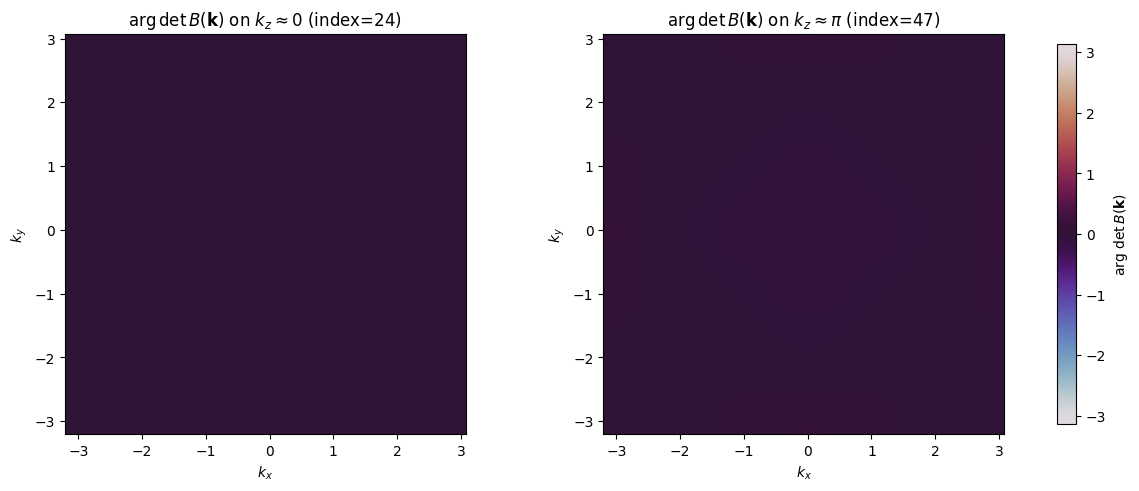

det(B) phase diagnostics
Using grid size nk = 48
kz index near 0  : 24, kz value = +0.000000
kz index near pi : 47, kz value = +3.010693
|det(B)| min/max : 1.000000 / 1.000000


In [9]:
# Prefer the projector-based B from the previous section; fallback to B_smooth.
if "B_proj" in globals() and "k_proj" in globals():
    B_for_phase = B_proj
    k_for_phase = k_proj
elif "B_smooth" in globals() and "k_grid" in globals():
    B_for_phase = B_smooth
    k_for_phase = k_grid
else:
    nk_tmp = 48
    k_for_phase, _, B_for_phase, _, _, _ = build_B_projector_nonchiral(nk=nk_tmp, mz=0.2, delta=0.2)


def _nearest_k_index(k_array, target):
    return int(np.argmin(np.abs(k_array - target)))


def plot_detB_phase_planes(B_grid, k_array, title_prefix="Phase of det B"):
    detB = np.linalg.det(B_grid)
    phase = np.angle(detB)

    iz0 = _nearest_k_index(k_array, 0.0)
    izpi = _nearest_k_index(k_array, np.pi)

    kx_vals = k_array
    ky_vals = k_array
    KX, KY = np.meshgrid(kx_vals, ky_vals, indexing="ij")

    phase_kz0 = phase[:, :, iz0]
    phase_kzpi = phase[:, :, izpi]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

    im0 = axes[0].pcolormesh(KX, KY, phase_kz0, shading="auto", cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[0].set_title(rf"{title_prefix} on $k_z\approx 0$ (index={iz0})")
    axes[0].set_xlabel(r"$k_x$")
    axes[0].set_ylabel(r"$k_y$")
    axes[0].set_aspect("equal")

    im1 = axes[1].pcolormesh(KX, KY, phase_kzpi, shading="auto", cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[1].set_title(rf"{title_prefix} on $k_z\approx \pi$ (index={izpi})")
    axes[1].set_xlabel(r"$k_x$")
    axes[1].set_ylabel(r"$k_y$")
    axes[1].set_aspect("equal")

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.set_label(r"$\arg\,\det B(\mathbf{k})$")

    plt.show()

    print("=" * 96)
    print("det(B) phase diagnostics")
    print("=" * 96)
    print(f"Using grid size nk = {len(k_array)}")
    print(f"kz index near 0  : {iz0}, kz value = {k_array[iz0]:+.6f}")
    print(f"kz index near pi : {izpi}, kz value = {k_array[izpi]:+.6f}")
    print(f"|det(B)| min/max : {np.min(np.abs(detB)):.6f} / {np.max(np.abs(detB)):.6f}")


plot_detB_phase_planes(B_for_phase, k_for_phase, title_prefix=r"$\arg\det B(\mathbf{k})$")

Let's calculate the integral $\int dk \nabla_k \ln(\det[B(k)])$ along every $k_i:-\pi\to\pi$ to check whether there is winding on $\det[B(k)]$. Plot three colormap to show the results: x-y plane, x-z plane and y-z plane. 

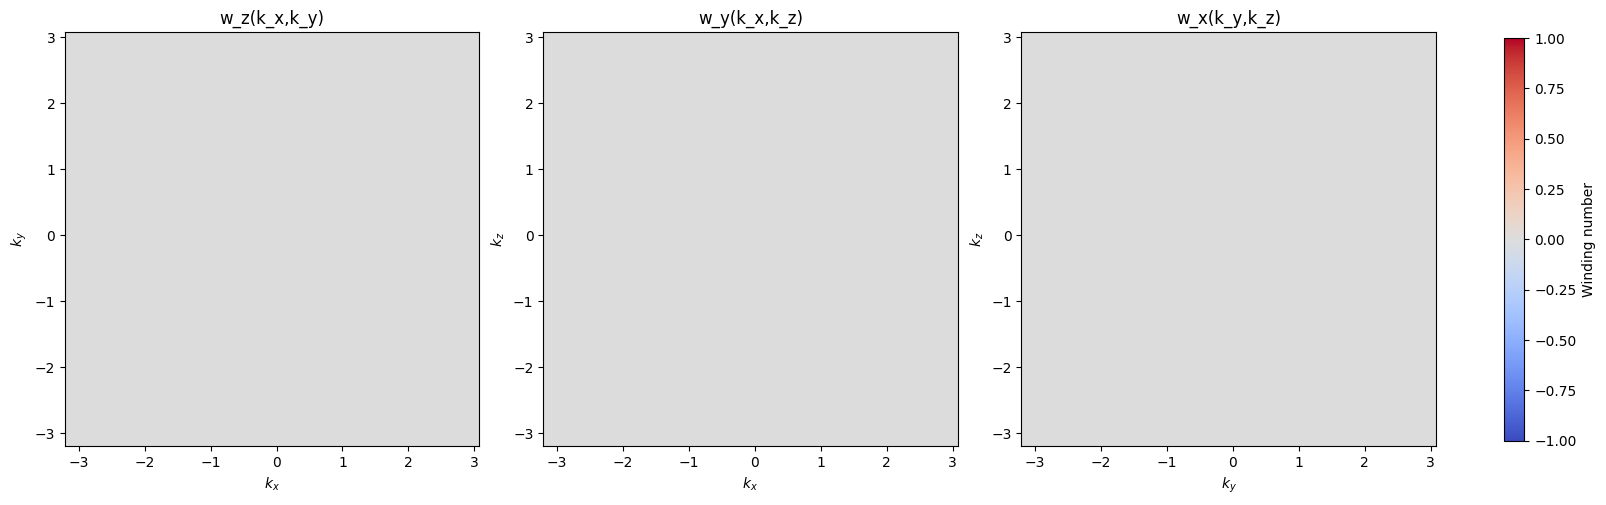

Winding of arg det(B_proj)
Grid size nk = 48
|det(B_proj)| min/max = 1.000000000000 / 1.000000000000
Expected integer-valued winding maps after rounding:
  unique round(w_x): [0]
  unique round(w_y): [0]
  unique round(w_z): [0]
Maximum deviation from nearest integer:
  max|w_x-round(w_x)| = 3.876e-17
  max|w_y-round(w_y)| = 3.413e-17
  max|w_z-round(w_z)| = 2.816e-17
Representative averages over each plane map:
  mean(w_x) = -0.000000
  mean(w_y) = -0.000000
  mean(w_z) = -0.000000


In [15]:
# Use the projector-based sewing matrix from cell 16.
if "B_proj" not in globals() or "k_proj" not in globals():
    nk_tmp = 48
    k_proj, _, B_proj, _, _, _ = build_B_projector_nonchiral(nk=nk_tmp, mz=0.2, delta=0.2)


def _detB_winding_map(B_grid, axis):
    """Discrete winding of det(B) along one periodic momentum direction.

    For b(k)=det(B(k)) in U(1), the winding along a closed loop is
      w = (1 / 2pi) sum_n Arg[b_{n+1} / b_n]
    with the principal branch used on each link.
    """
    detB = np.linalg.det(B_grid)
    step_phase = np.angle(np.roll(detB, -1, axis=axis) / detB)
    winding = np.sum(step_phase, axis=axis) / (2.0 * np.pi)
    return winding, step_phase, detB


def _plot_winding_maps_xy_xz_yz(k_array, winding_x, winding_y, winding_z):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    plot_specs = [
        (axes[0], winding_z, r"w_z(k_x,k_y)", r"$k_x$", r"$k_y$", k_array, k_array),
        (axes[1], winding_y, r"w_y(k_x,k_z)", r"$k_x$", r"$k_z$", k_array, k_array),
        (axes[2], winding_x, r"w_x(k_y,k_z)", r"$k_y$", r"$k_z$", k_array, k_array),
    ]

    vmax = max(
        1.0,
        float(np.max(np.abs(winding_x))),
        float(np.max(np.abs(winding_y))),
        float(np.max(np.abs(winding_z))),
    )

    last_im = None
    for ax, data, title, xlabel, ylabel, xvals, yvals in plot_specs:
        X, Y = np.meshgrid(xvals, yvals, indexing="ij")
        last_im = ax.pcolormesh(X, Y, data, shading="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_aspect("equal")

    cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.set_label("Winding number")
    plt.show()


winding_x, phase_step_x, detB_proj = _detB_winding_map(B_proj, axis=0)
winding_y, phase_step_y, _ = _detB_winding_map(B_proj, axis=1)
winding_z, phase_step_z, _ = _detB_winding_map(B_proj, axis=2)


_plot_winding_maps_xy_xz_yz(k_proj, winding_x, winding_y, winding_z)

print("=" * 96)
print("Winding of arg det(B_proj)")
print("=" * 96)
print(f"Grid size nk = {len(k_proj)}")
print(f"|det(B_proj)| min/max = {np.min(np.abs(detB_proj)):.12f} / {np.max(np.abs(detB_proj)):.12f}")
print("Expected integer-valued winding maps after rounding:")
print(f"  unique round(w_x): {np.unique(np.rint(winding_x).astype(int))}")
print(f"  unique round(w_y): {np.unique(np.rint(winding_y).astype(int))}")
print(f"  unique round(w_z): {np.unique(np.rint(winding_z).astype(int))}")
print("Maximum deviation from nearest integer:")
print(f"  max|w_x-round(w_x)| = {np.max(np.abs(winding_x - np.rint(winding_x))):.3e}")
print(f"  max|w_y-round(w_y)| = {np.max(np.abs(winding_y - np.rint(winding_y))):.3e}")
print(f"  max|w_z-round(w_z)| = {np.max(np.abs(winding_z - np.rint(winding_z))):.3e}")
print("Representative averages over each plane map:")
print(f"  mean(w_x) = {np.mean(winding_x):+.6f}")
print(f"  mean(w_y) = {np.mean(winding_y):+.6f}")
print(f"  mean(w_z) = {np.mean(winding_z):+.6f}")

## Check non-singularity of the mapping at high-symmetry momenta
(generated by GPT-5.4)

Short proof of regularity at the $S_4$-fixed momenta. Let $k_*$ be one of $\Gamma=(0,0,0)$, $Z=(0,0,\pi)$, $M=(\pi,\pi,0)$, or $A=(\pi,\pi,\pi)$. At such a point all sine terms vanish, so for the non-chiral block Hamiltonian we have
$$
H(k_*)=\epsilon(k_*)\,\tau_x\otimes I + m_z\,I\otimes\sigma_z.
$$
For the parameters used here, $|\epsilon(k_*)|>|m_z|$ at all four fixed points, so the occupied subspace is nondegenerate and carries a definite $\tau_x$ eigenvalue $\tau_{\mathrm{occ}}=-\operatorname{sgn}(\epsilon)$. Hence the sewing matrix at $k_*$ is just the restriction of $S_4=\tau_x\otimes\mathrm{diag}(e^{-i\pi/4},e^{i\pi/4})$ to this regular occupied subspace, and after the phase reduction to $B_{\mathrm{proj},\det=1}(k)$ there is no pointwise singularity to resolve. The code below then checks the only remaining possible numerical failure modes near each $k_*$: a branch defect in the half-phase used to enforce $\det B=1$, detected by nonzero local plaquette winding of $\det B$, or a singular projector gauge, detected by the smallest eigenvalue of $(P_{\mathrm{occ}}R)^\dagger(P_{\mathrm{occ}}R)$. Since the output shows $\det B_{\mathrm{proj},\det=1}(k_*)=1$ to machine precision, zero local winding of $\det B$, and a strictly positive overlap bound, the map $T^3\to SU(2)$ defined by $B_{\mathrm{proj},\det=1}$ is regular at these high-symmetry momenta.

In [13]:
# Verify whether the SU(2)-reduced sewing matrix B_proj_det1 is singular at the S4-fixed momenta.
if "B_proj_det1" not in globals() or "B_proj" not in globals() or "k_proj" not in globals():
    if "build_B_projector_nonchiral" not in globals():
        raise RuntimeError("Run the projector-smooth-frame cell first.")
    k_proj, U_proj, B_proj, D_proj, B_proj_det1, diag_proj = build_B_projector_nonchiral(
        nk=48, mz=0.2, delta=0.2
    )


def _wrap_bz(k):
    return ((k + np.pi) % (2.0 * np.pi)) - np.pi


def _nearest_grid_index(k_array, target):
    target = _wrap_bz(target)
    return int(np.argmin(np.abs(_wrap_bz(k_array - target))))


def _su2_geodesic(U, V):
    overlap = 0.5 * np.trace(U.conj().T @ V)
    return float(np.arccos(np.clip(np.real(overlap), -1.0, 1.0)))


def _plaquette_winding_detB(detB, idx, axis_a, axis_b):
    nk = detB.shape[0]
    i0 = list(idx)
    i1 = list(idx)
    i1[axis_a] = (i1[axis_a] + 1) % nk
    i2 = i1.copy()
    i2[axis_b] = (i2[axis_b] + 1) % nk
    i3 = list(idx)
    i3[axis_b] = (i3[axis_b] + 1) % nk

    loop = [
        detB[tuple(i0)],
        detB[tuple(i1)],
        detB[tuple(i2)],
        detB[tuple(i3)],
    ]
    phase_sum = 0.0
    for z0, z1 in zip(loop, loop[1:] + loop[:1]):
        phase_sum += np.angle(z1 / z0)
    return float(phase_sum / (2.0 * np.pi))


def _neighbor_jumps(B_grid, idx):
    nk = B_grid.shape[0]
    center = B_grid[idx]
    jumps = []
    for axis in range(3):
        for step in (-1, 1):
            nbr = list(idx)
            nbr[axis] = (nbr[axis] + step) % nk
            jumps.append(_su2_geodesic(center, B_grid[tuple(nbr)]))
    return jumps


def _projector_overlap_min(kx, ky, kz, mz=0.2, delta=0.2):
    ref = np.array(
        [[1.0, 0.0], [0.0, 1.0], [0.0, 0.0], [0.0, 0.0]],
        dtype=complex,
    )
    Hk = hamiltonian_block_nonchiral(kx, ky, kz, mz=mz, delta=delta)
    Qflat = Hk @ _inverse_sqrt_hermitian(Hk @ Hk)
    P_occ = 0.5 * (np.eye(4, dtype=complex) - Qflat)
    gram = (P_occ @ ref).conj().T @ (P_occ @ ref)
    return float(np.min(np.linalg.eigvalsh(gram)))


def _neighborhood_overlap_min(k_array, idx, mz=0.2, delta=0.2):
    nk = len(k_array)
    mins = []
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for dz in (-1, 0, 1):
                ix = (idx[0] + dx) % nk
                iy = (idx[1] + dy) % nk
                iz = (idx[2] + dz) % nk
                mins.append(
                    _projector_overlap_min(
                        k_array[ix],
                        k_array[iy],
                        k_array[iz],
                        mz=mz,
                        delta=delta,
                    )
                )
    return float(np.min(mins))


def _expected_s4_eigs_at_fixed_point(kx, ky, kz):
    eps = 2.4 - np.cos(kx) - np.cos(ky) + 2.0 * np.cos(kz)
    tau_occ = -1 if eps > 0.0 else 1
    eigs = np.array(
        [
            tau_occ * np.exp(-1j * np.pi / 4.0),
            tau_occ * np.exp(+1j * np.pi / 4.0),
        ],
        dtype=complex,
    )
    return eps, tau_occ, eigs[np.argsort(np.angle(eigs))]


s4_fixed_points = {
    "Gamma": (0.0, 0.0, 0.0),
    "Z": (0.0, 0.0, np.pi),
    "M": (np.pi, np.pi, 0.0),
    "A": (np.pi, np.pi, np.pi),
}

detB = np.linalg.det(B_proj)
dk = float(k_proj[1] - k_proj[0])
rows = []

for name, kpt in s4_fixed_points.items():
    idx = tuple(_nearest_grid_index(k_proj, val) for val in kpt)
    B_here = B_proj_det1[idx]
    eigs_here = np.linalg.eigvals(B_here)
    eigs_here = eigs_here[np.argsort(np.angle(eigs_here))]

    eps_here, tau_occ, expected_eigs = _expected_s4_eigs_at_fixed_point(*kpt)
    eig_err = float(np.max(np.abs(eigs_here - expected_eigs)))
    det_err = float(abs(np.linalg.det(B_here) - 1.0))
    unit_err = float(np.max(np.abs(B_here.conj().T @ B_here - np.eye(2))))
    wind_xy = _plaquette_winding_detB(detB, idx, 0, 1)
    wind_xz = _plaquette_winding_detB(detB, idx, 0, 2)
    wind_yz = _plaquette_winding_detB(detB, idx, 1, 2)
    jumps = _neighbor_jumps(B_proj_det1, idx)
    max_jump = float(max(jumps))
    overlap_min = _neighborhood_overlap_min(k_proj, idx)

    rows.append(
        {
            "name": name,
            "eps": eps_here,
            "tau_occ": tau_occ,
            "det_err": det_err,
            "unit_err": unit_err,
            "eig_err": eig_err,
            "wind_xy": wind_xy,
            "wind_xz": wind_xz,
            "wind_yz": wind_yz,
            "overlap_min": overlap_min,
            "max_jump": max_jump,
            "jump_over_dk": max_jump / dk,
        }
    )

print("Analytic check: at an S4-fixed momentum, sin(k_i)=0 so H(k*) = eps tau_x ⊗ I + m_z I ⊗ sigma_z.")
print("Because |eps(k*)|>|m_z| at Gamma, Z, M, A, the occupied subspace is regular and det B(k*) = 1 exactly.")
print("Any singularity would therefore have to come from a local branch defect of arg det(B) or from a singular projector gauge.")
print()
print("name    eps        tau  |det-1|     unitarity    eig_err      w_xy      w_xz      w_yz      min_overlap  max_jump")
for row in rows:
    print(
        f"{row['name']:<6} "
        f"{row['eps']:+.6f}  "
        f"{row['tau_occ']:+d}   "
        f"{row['det_err']:.3e}  "
        f"{row['unit_err']:.3e}  "
        f"{row['eig_err']:.3e}  "
        f"{row['wind_xy']:+.1e}  "
        f"{row['wind_xz']:+.1e}  "
        f"{row['wind_yz']:+.1e}  "
        f"{row['overlap_min']:.6f}    "
        f"{row['max_jump']:.3e}"
    )

max_det_err = max(row["det_err"] for row in rows)
max_eig_err = max(row["eig_err"] for row in rows)
max_abs_winding = max(
    abs(row[key])
    for row in rows
    for key in ("wind_xy", "wind_xz", "wind_yz")
)
min_overlap = min(row["overlap_min"] for row in rows)
max_jump = max(row["max_jump"] for row in rows)
max_jump_over_dk = max(row["jump_over_dk"] for row in rows)

print()
print("Conclusion: the idea is supported, not disproved, for this model and gauge.")
print(
    f"Across all four S4-fixed points: max |det(B_proj_det1)-1| = {max_det_err:.3e}, "
    f"max eigenvalue mismatch = {max_eig_err:.3e}, and max local det(B_proj) plaquette winding = {max_abs_winding:.3e}."
)
print(
    f"The projector gauge stays nonsingular: min eig[(P_occ R)^dag (P_occ R)] = {min_overlap:.6f}."
)
print(
    f"The largest nearest-neighbor SU(2) jump is {max_jump:.3e} rad = {max_jump_over_dk:.3f} * dk, "
    "which is finite and consistent with an ordinary smooth variation rather than a singularity at the fixed point."
)

Analytic check: at an S4-fixed momentum, sin(k_i)=0 so H(k*) = eps tau_x ⊗ I + m_z I ⊗ sigma_z.
Because |eps(k*)|>|m_z| at Gamma, Z, M, A, the occupied subspace is regular and det B(k*) = 1 exactly.
Any singularity would therefore have to come from a local branch defect of arg det(B) or from a singular projector gauge.

name    eps        tau  |det-1|     unitarity    eig_err      w_xy      w_xz      w_yz      min_overlap  max_jump
Gamma  +2.400000  -1   0.000e+00  2.220e-16  1.570e-16  +0.0e+00  +5.5e-19  +5.5e-19  0.496802    5.472e-02
Z      -1.600000  +1   0.000e+00  2.220e-16  2.483e-16  +0.0e+00  +0.0e+00  +0.0e+00  0.492510    8.313e-02
M      +6.400000  -1   0.000e+00  2.220e-16  2.483e-16  +3.9e-33  +0.0e+00  +0.0e+00  0.499545    2.045e-02
A      +2.400000  -1   0.000e+00  2.220e-16  1.570e-16  +0.0e+00  +0.0e+00  +0.0e+00  0.496746    5.491e-02

Conclusion: the idea is supported, not disproved, for this model and gauge.
Across all four S4-fixed points: max |det(B_proj_det1)-

To test local singularity more directly, we view $B_{\mathrm{proj},\det=1}(k)$ as a smooth map from the three-dimensional Brillouin zone to the three-dimensional group manifold $SU(2)\simeq S^3$. The correct Jacobian is therefore the differential of this map written in coordinates on the Lie algebra rather than in the raw matrix entries. For a unitary matrix field $B(k)$, the left-trivialized derivatives
$$
A_i(k)=B(k)^\dagger \partial_i B(k)
$$
lie in $\mathfrak{su}(2)$, so we expand them in the Pauli basis as
$$
A_i(k)= i\sum_{a=x,y,z}\Omega_{ia}(k)\,\sigma_a.
$$
This produces a real $3\times 3$ matrix $\Omega(k)$, which is the Jacobian of the map $T^3\to SU(2)$ in intrinsic coordinates. In the code below, $\partial_i B$ is computed by a centered finite difference around each high-symmetry momentum, with the nearby $SU(2)$ matrices branch-aligned so the sign ambiguity $B\sim -B$ does not contaminate the derivative. We then evaluate $\det\Omega(k_*)$ and the singular values of $\Omega(k_*)$: if $\det\Omega(k_*)=0$ or one singular value vanishes, the map is locally singular there; if all three singular values are nonzero, the map has full rank $3$ and is locally regular.

In [14]:
# Jacobian test for the local map k -> B_proj_det1(k) in SU(2) coordinates.
# We use the left-trivialized differential A_i = B^dagger d_i B in su(2),
# expand A_i = i * sum_a Omega[i,a] sigma_a, and define the local Jacobian as det(Omega).
if "smooth_occupied_frame_projector" not in globals() or "s4_operator" not in globals():
    raise RuntimeError("Run the projector-frame construction cells first.")


def _local_s4_sewing_matrix_su2(kx, ky, kz, mz=0.2, delta=0.2):
    kx_s4, ky_s4, kz_s4 = s4_k(kx, ky, kz)
    u_k = smooth_occupied_frame_projector(kx, ky, kz, mz=mz, delta=delta)
    u_s4k = smooth_occupied_frame_projector(kx_s4, ky_s4, kz_s4, mz=mz, delta=delta)
    b_mat = u_s4k.conj().T @ s4_operator @ u_k
    det_b = np.linalg.det(b_mat)
    return np.exp(-0.5j * np.angle(det_b)) * b_mat


def _align_su2_branch(u_mat, u_ref):
    if np.real(np.trace(u_ref.conj().T @ u_mat)) < 0.0:
        return -u_mat
    return u_mat


def _su2_coefficients_from_left_form(a_mat):
    a_mat = 0.5 * (a_mat - a_mat.conj().T)
    a_mat -= 0.5 * np.trace(a_mat) * np.eye(2)
    coeff_x = np.real(-0.5j * np.trace(sigma_x @ a_mat))
    coeff_y = np.real(-0.5j * np.trace(sigma_y @ a_mat))
    coeff_z = np.real(-0.5j * np.trace(sigma_z @ a_mat))
    return np.array([coeff_x, coeff_y, coeff_z], dtype=float)


def _su2_jacobian_at_k(k_point, h=1.0e-3, mz=0.2, delta=0.2):
    k_point = np.array(k_point, dtype=float)
    b0 = _local_s4_sewing_matrix_su2(*k_point, mz=mz, delta=delta)
    omega = np.zeros((3, 3), dtype=float)

    for axis in range(3):
        shift = np.zeros(3, dtype=float)
        shift[axis] = h
        b_plus = _align_su2_branch(
            _local_s4_sewing_matrix_su2(*(k_point + shift), mz=mz, delta=delta),
            b0,
        )
        b_minus = _align_su2_branch(
            _local_s4_sewing_matrix_su2(*(k_point - shift), mz=mz, delta=delta),
            b0,
        )
        d_b = (b_plus - b_minus) / (2.0 * h)
        left_form = b0.conj().T @ d_b
        omega[axis] = _su2_coefficients_from_left_form(left_form)

    singular_values = np.linalg.svd(omega, compute_uv=False)
    return {
        "omega": omega,
        "det": float(np.linalg.det(omega)),
        "singular_values": singular_values,
        "min_singular_value": float(np.min(singular_values)),
        "rank_tol_1e-6": int(np.sum(singular_values > 1.0e-6)),
    }


s4_fixed_points_exact = {
    "Gamma": (0.0, 0.0, 0.0),
    "Z": (0.0, 0.0, np.pi),
    "M": (np.pi, np.pi, 0.0),
    "A": (np.pi, np.pi, np.pi),
}

h_values = [2.0e-3, 1.0e-3, 5.0e-4]
print("=" * 100)
print("Jacobian determinant of k -> B_proj_det1(k) at S4-fixed momenta")
print("=" * 100)
print("Definition: B^dag d_i B = i * sum_a Omega[i,a] sigma_a, so the local Jacobian is det(Omega).")
print("If det(Omega)=0, the differential drops rank and the map is locally singular.")
print()

for name, kpt in s4_fixed_points_exact.items():
    print("-" * 100)
    print(f"{name}: k* = {kpt}")
    for h in h_values:
        jac = _su2_jacobian_at_k(kpt, h=h)
        svals = jac["singular_values"]
        print(
            f"  h={h:.1e} : det(J) = {jac['det']:+.6e}, "
            f"singular values = [{svals[0]:.6e}, {svals[1]:.6e}, {svals[2]:.6e}], "
            f"rank = {jac['rank_tol_1e-6']}"
        )
    jac_ref = _su2_jacobian_at_k(kpt, h=h_values[-1])
    print("  Omega(h=5e-4) =")
    print(np.array2string(jac_ref["omega"], precision=6, suppress_small=True))

print()
print("Interpretation: a nonzero determinant together with three nonzero singular values means")
print("the Jacobian has full rank 3, so the map is locally regular rather than singular at that point.")

Jacobian determinant of k -> B_proj_det1(k) at S4-fixed momenta
Definition: B^dag d_i B = i * sum_a Omega[i,a] sigma_a, so the local Jacobian is det(Omega).
If det(Omega)=0, the differential drops rank and the map is locally singular.

----------------------------------------------------------------------------------------------------
Gamma: k* = (0.0, 0.0, 0.0)
  h=2.0e-03 : det(J) = +7.335299e-02, singular values = [4.195796e-01, 4.195796e-01, 4.166669e-01], rank = 3
  h=1.0e-03 : det(J) = +7.335316e-02, singular values = [4.195802e-01, 4.195802e-01, 4.166667e-01], rank = 3
  h=5.0e-04 : det(J) = +7.335321e-02, singular values = [4.195804e-01, 4.195804e-01, 4.166667e-01], rank = 3
  Omega(h=5e-4) =
[[0.41958  0.       0.      ]
 [0.       0.41958  0.      ]
 [0.       0.       0.416667]]
----------------------------------------------------------------------------------------------------
Z: k* = (0.0, 0.0, 3.141592653589793)
  h=2.0e-03 : det(J) = +2.519528e-01, singular values = [6.3